In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
dataset= pd.read_csv('Digital_Marketing_DP.csv')
dataset.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

In [5]:
#Descriptive summary 
from univariate2 import Univariate
quan,qual=Univariate.quanQual(dataset)
Univariate.Descriptive(quan,dataset)

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
Mean,11999.5,43.6255,84664.19675,5000.94483,0.154829,0.104389,24.751625,5.549299,7.727718,49.79975,9.476875,4.467375,4.4855,2490.2685,0.8765
Median,11999.5,43.0,84926.5,5013.440044,0.154505,0.104046,25.0,5.534257,7.682956,50.0,9.0,4.0,4.0,2497.0,1.0
Mode,8000,64,50268,100.054813,0.010005,0.010018,25,1.000428,0.501669,61,9,4,0,1392,1
Q1:25%,9999.75,31.0,51744.5,2523.221165,0.082635,0.05641,13.0,3.302479,4.06834,25.0,5.0,2.0,2.0,1254.75,1.0
Q2:50%,11999.5,43.0,84926.5,5013.440044,0.154505,0.104046,25.0,5.534257,7.682956,50.0,9.0,4.0,4.0,2497.0,1.0
Q3:75%,13999.25,56.0,116815.75,7407.989369,0.228207,0.152077,37.0,7.835756,11.481468,75.0,14.0,7.0,7.0,3702.25,1.0
99%,15919.01,69.0,148424.21,9901.971843,0.297385,0.197881,49.0,9.90729,14.864002,98.0,19.0,9.0,9.0,4947.0,1.0
Q4:100%,15999.0,69.0,149986.0,9997.914781,0.299968,0.199995,49.0,9.999055,14.995311,99.0,19.0,9.0,9.0,4999.0,1.0
IQR,3999.5,25.0,65071.25,4884.768205,0.145572,0.095667,24.0,4.533277,7.413128,50.0,9.0,5.0,5.0,2447.5,0.0
1.5 rule,5999.25,37.5,97606.875,7327.152307,0.218358,0.143501,36.0,6.799915,11.119693,75.0,13.5,7.5,7.5,3671.25,0.0


In [47]:
#1. How many users converted vs not converted

In [6]:
dataset['Conversion'].value_counts()

Conversion
1    7012
0     988
Name: count, dtype: int64

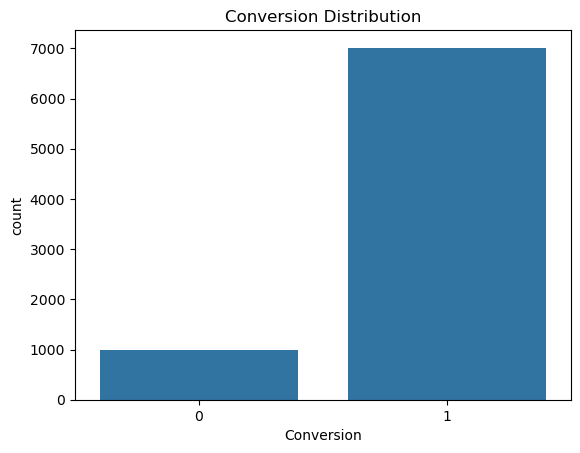

In [7]:
sns.countplot(x='Conversion', data=dataset)
plt.title("Conversion Distribution")
plt.show()

In [50]:
#2.Which campaign brings more conversion

In [8]:
channel_conversion = dataset.groupby('CampaignChannel')['Conversion'].mean()

print(channel_conversion.sort_values(ascending=False))

CampaignChannel
Referral        0.883072
PPC             0.882779
SEO             0.876774
Email           0.870263
Social Media    0.868334
Name: Conversion, dtype: float64


In [52]:
#3.Through Which campaign user spent more time on site

In [9]:
channel_time = dataset.groupby('CampaignChannel')['TimeOnSite'].max()

print(channel_time.sort_values(ascending=False))

CampaignChannel
PPC             14.995311
SEO             14.995026
Social Media    14.994551
Email           14.984303
Referral        14.979306
Name: TimeOnSite, dtype: float64


In [54]:
#4. Does higher ad spends result in conversion

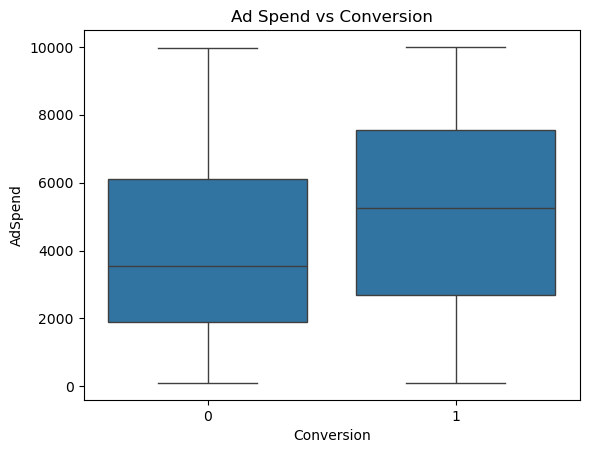

In [10]:
sns.boxplot(x='Conversion', y='AdSpend', data=dataset)
plt.title("Ad Spend vs Conversion")
plt.show()

In [11]:
dataset[['AdSpend', 'Conversion']].corr()

,AdSpend,Conversion
AdSpend,1.000000,0.124672
Conversion,0.124672,1.000000


In [12]:
#5. Does reported visitors return to purchase

In [58]:
dataset[['PreviousPurchases', 'Conversion']].corr()

,PreviousPurchases,Conversion
PreviousPurchases,1.000000,0.111781
Conversion,0.111781,1.000000


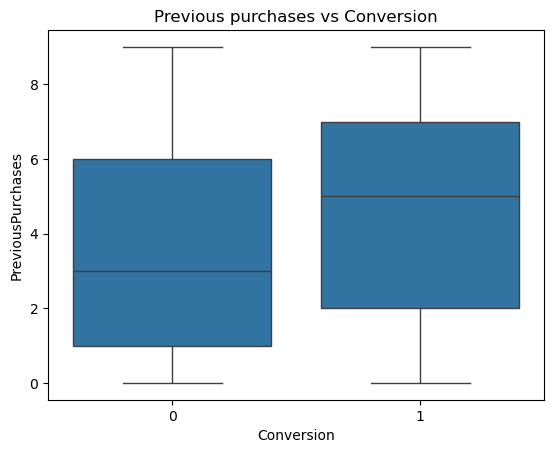

In [13]:
sns.boxplot(x='Conversion', y='PreviousPurchases', data=dataset)
plt.title("Previous purchases vs Conversion")
plt.show()

In [14]:
#6. Studiying distributions of numerical type

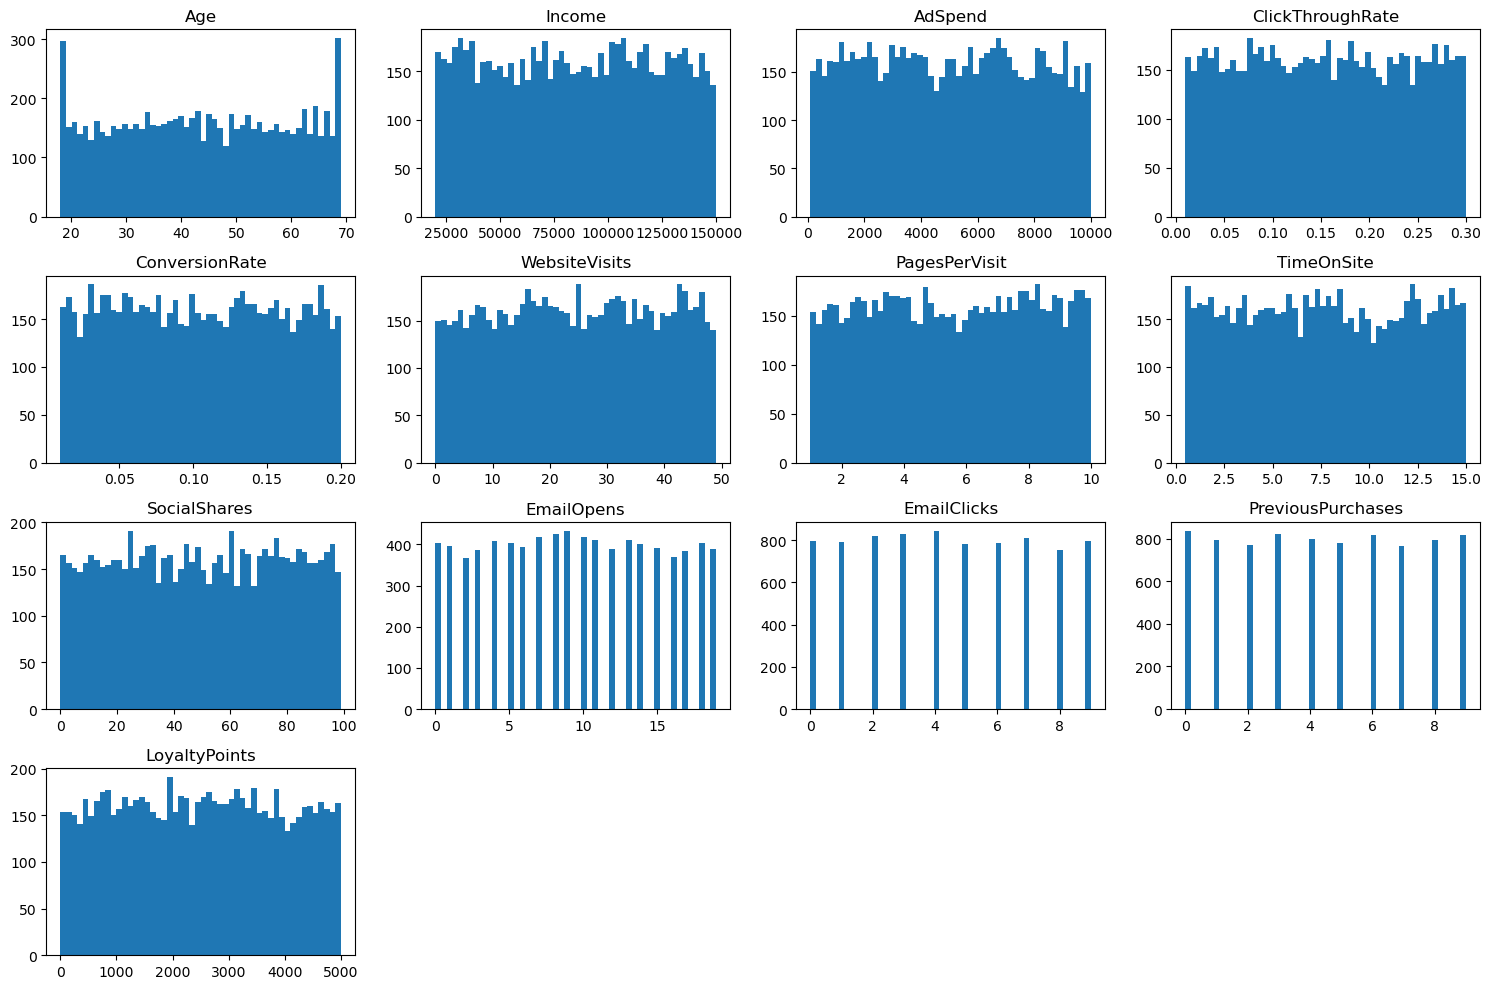

In [15]:
columns_to_plot = [col for col in dataset.columns if col not in ['CustomerID','Gender','AdvertisingTool','CampaignChannel','CampaignType','AdvertisingPlatform','Conversion']]

fig, axes = plt.subplots(4, 4, figsize=(15, 10))  
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    axes[i].hist(dataset[col], bins=50)
    axes[i].set_title(col) 

for i in range(len(columns_to_plot), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [70]:
#7.Studying distributions of categorical type

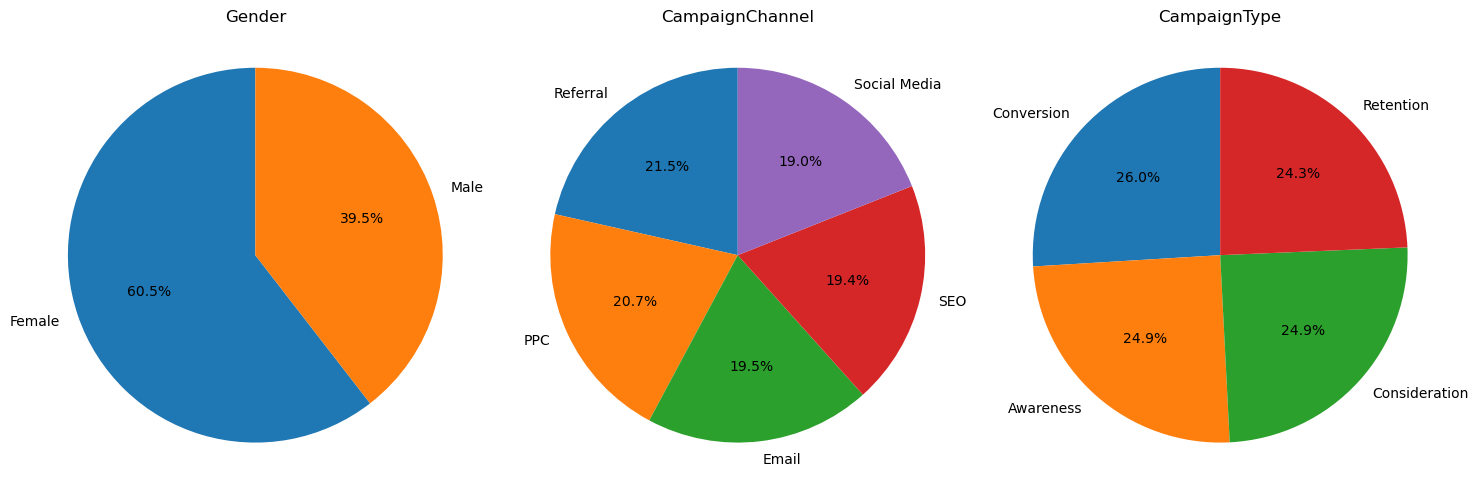

In [16]:
#Proportions in categorical features
categorical_columns = dataset.select_dtypes(include='object').columns

#Ignoring the last 2 categorical columns as they are confidential
cols_to_plot = categorical_columns[:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cols_to_plot):
    proportions = dataset[col].value_counts(normalize=True)
    axes[i].pie(proportions, labels=proportions.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(col)
    axes[i].axis('equal') 

plt.tight_layout()
plt.show()

In [73]:
#8. Does website engagement impact conversion


In [17]:
dataset[['WebsiteVisits','TimeOnSite','PagesPerVisit', 'Conversion']].corr()

,WebsiteVisits,TimeOnSite,PagesPerVisit,Conversion
WebsiteVisits,1.000000,-0.022440,-0.011891,0.079339
TimeOnSite,-0.022440,1.000000,0.016455,0.129609
PagesPerVisit,-0.011891,0.016455,1.000000,0.102840
Conversion,0.079339,0.129609,0.102840,1.000000


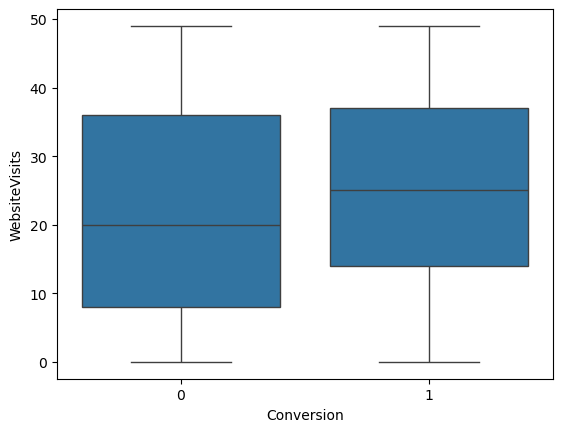

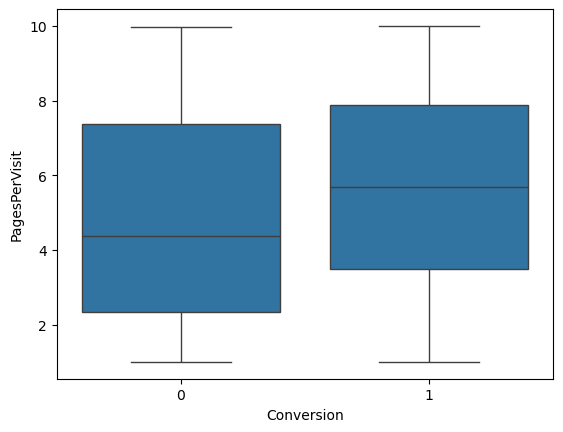

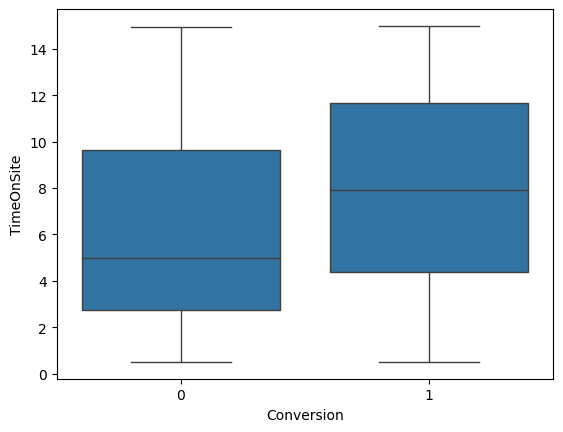

In [18]:
engagement_cols = ['WebsiteVisits','PagesPerVisit','TimeOnSite']

for col in engagement_cols:
    sns.boxplot(x='Conversion', y=col, data=dataset)
    plt.show()

In [77]:
#9. Important features that related with conversion


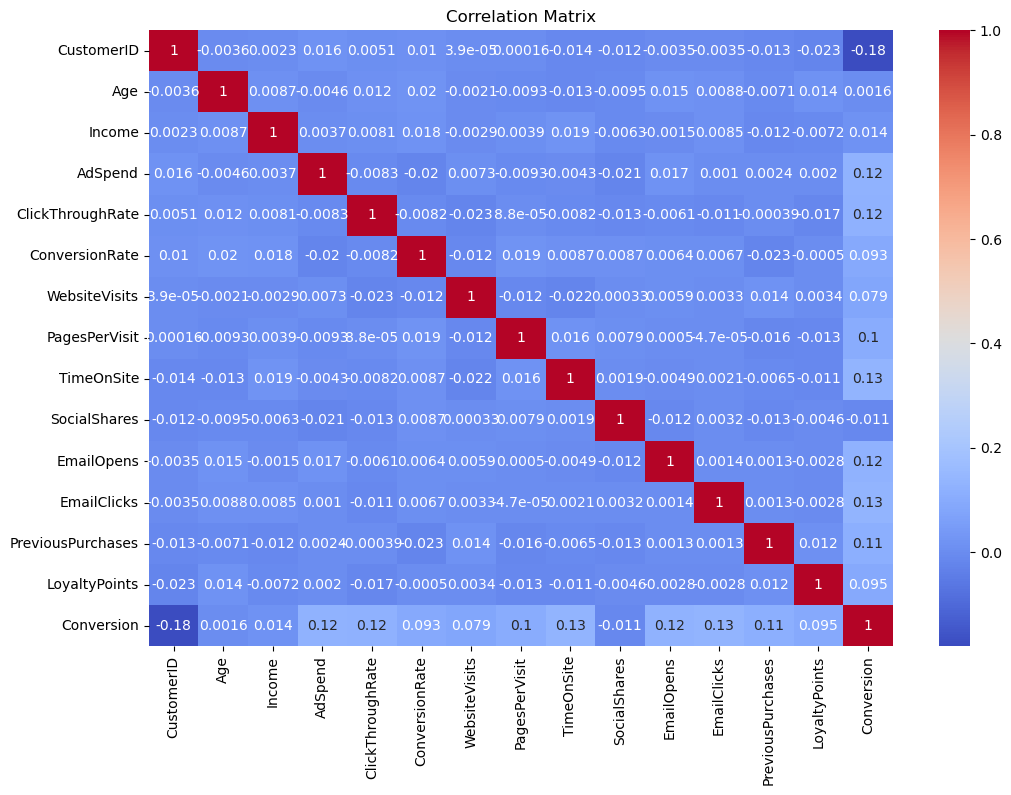

In [19]:
numeric_df = dataset.select_dtypes(include='number')

corr = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [79]:
#10. chekcing outliers in user behaviour

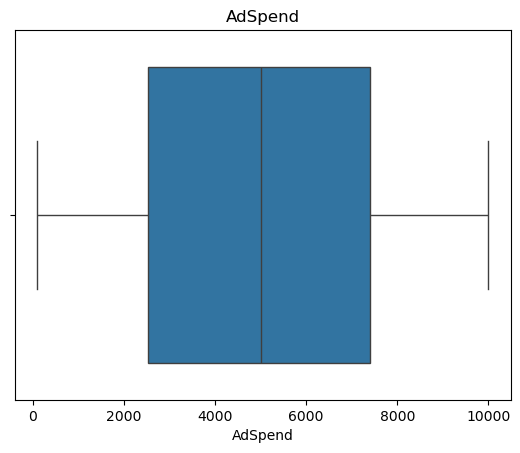

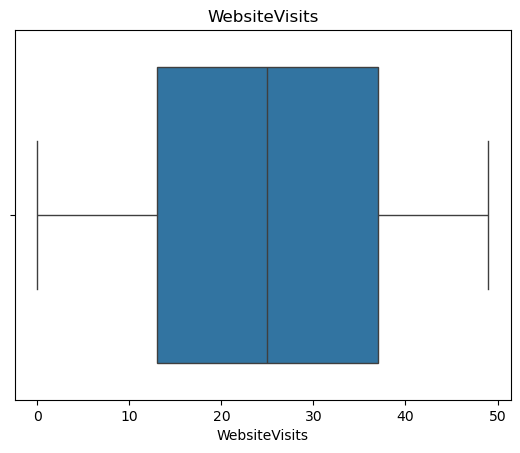

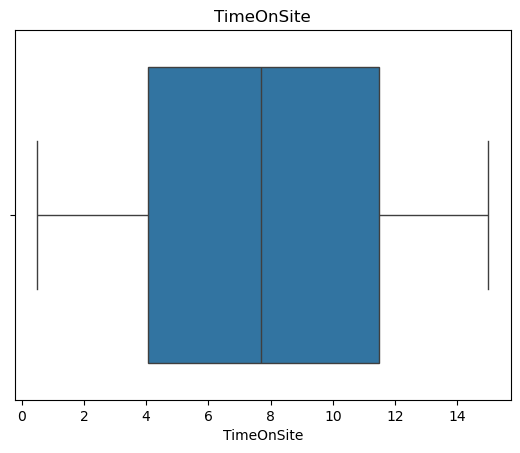

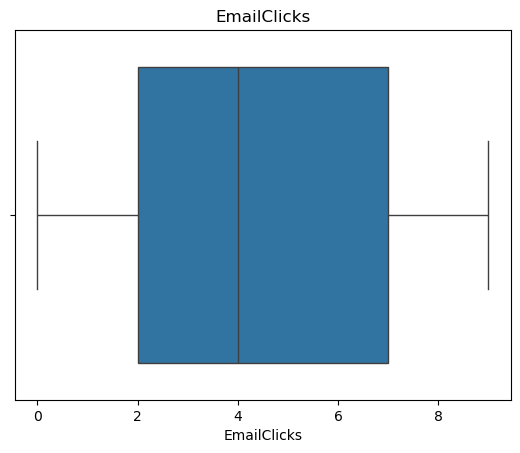

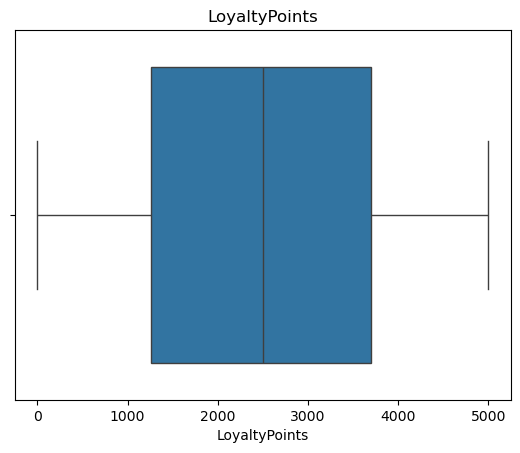

In [80]:
cols = ['AdSpend',
        'WebsiteVisits',
        'TimeOnSite',
        'EmailClicks',
        'LoyaltyPoints']

for col in cols:
    sns.boxplot(x=dataset[col])
    plt.title(col)
    plt.show()

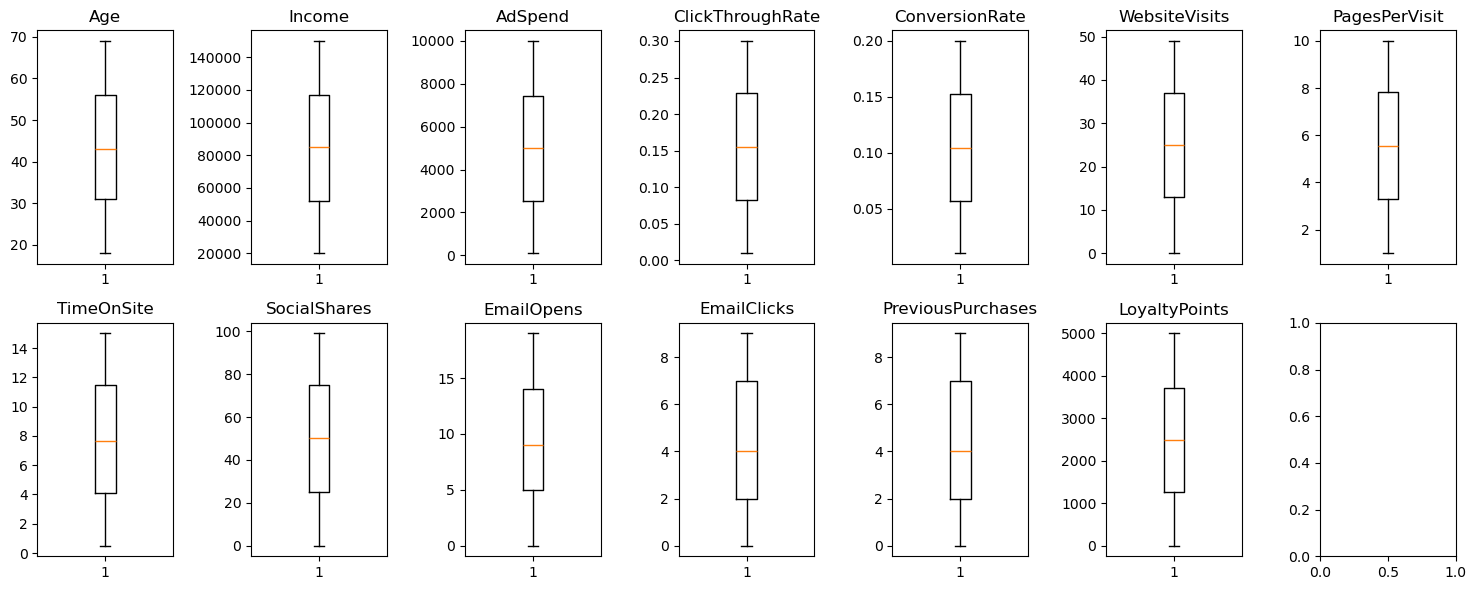

In [20]:
#check outliers using box plots for numberical data
fig, axes = plt.subplots(2, 7, figsize=(15, 6))  
axes = axes.flatten()

for i, column in enumerate(columns_to_plot):
        axes[i].boxplot(dataset[column])
        axes[i].set_title(column)

plt.tight_layout()
plt.show()